In [21]:
import numpy as np
from numpy import round
import matplotlib.pyplot as plt
from tqdm import tqdm

In [22]:

def gamma_k(_kx, _ky):
    return (np.cos(_kx) + np.cos(_ky))/2

def gamma2_k(_kx, _ky):
    return 1/4 * (np.cos(_kx) + np.cos(_ky))**2

def a_func(t, n, delta = 1., lamb = 0.):
    return 2 * (delta + t - 2 * n * (t/2 + lamb * delta))

def b_func(t, n, I, delta = 1., lamb = 0.):
    return 2 * (1 - 2 * n + I + t * (t/2 + lamb * delta) )

def get_bog_pars(t, n, I, _kx, _ky, delta = 1., lamb = 0.):
    a = a_func(t, n, delta, lamb)
    b = b_func(t, n, I, delta, lamb)

    wk = np.abs(np.sqrt(a**2 - b**2 * gamma2_k(_kx, _ky) + 0j))
    
    alpha_plus = np.sqrt(1/2 * (a/wk + 1) + 0j)
    alpha_minus = np.sign(gamma_k(_kx, _ky)) * np.sqrt(1/2 * (a/wk - 1) + 0j)

    return a, b, wk, alpha_plus, alpha_minus

def t_func(b, wk, gamma2k, N):
    return np.abs(b)/N * np.real(np.sum(gamma2k / wk))

def n_func(a, wk, N):
    return 1/(2*N) * np.sum(np.abs(a/wk - 1))

def I_func(a_plus_k, a_minus_k, a_plus_q, a_minus_q, kx, ky, qx, qy, N):
    return 1/(2*N**2) * np.sum(np.real(a_plus_k * a_minus_k * np.conj(a_plus_q * a_minus_q)) * 2 * gamma_k(kx + qx, ky + qy)
                         + (np.abs(a_minus_k)**2 * np.abs(a_plus_q)**2) * 2 * gamma_k(kx - qx, ky - qy))

In [23]:
def disp(n, t, I, delta = 1., l = 0., _print = True):

    ak = a_func(t, n, delta, l)
    bk = b_func(t, n, I, delta, l)

    #print(f'Ak = {round(ak, 5)}, Bk = {round(bk, 5)}')

    const = 0.

    if bk**2 > ak**2:
        if _print:
            print('IMAGINARY')
        const = 0j
    
    gap_g = np.sqrt(np.abs(ak)**2 - np.abs(bk)**2 + const)
    gap_x = np.sqrt(np.abs(ak)**2)

    if _print:
        print(f'Ak = {round(ak, 5)}, Bk = {round(bk, 5)}')
        print(f'Gap at G point: {round(gap_g, 3)}')
        print(f'Gap at X point: {round(gap_x, 3)}')

    return gap_g, gap_x

In [24]:
def get_flow(n, t, delta = 1., lamb = 0., I = .2, leapfrog : bool = False, k_bins = 50):
    # strating parameters
    n_old = n
    t_old = t
    I_old = I

    N = k_bins**2
    k = np.linspace(-np.pi, np.pi, k_bins, endpoint = False)

    px, py = np.meshgrid(k, k, indexing = 'ij')
    kx, ky, qx, qy = np.meshgrid(k, k, k, k, indexing = 'ij')

    # get general parameters
    a, b, wk, apk, amk = get_bog_pars(t_old, n_old, I_old, px, py, delta, lamb)
    gamma2k = gamma2_k(px, py)

    # get new t
    t_new = t_func(b, wk, gamma2k, N)

    # if leapfrog -> update t and delta_k
    if leapfrog:
        t_old = t_new
        a, b, wk, apk, amk = get_bog_pars(t_old, n_old, I_old, px, py, delta, lamb)

    # get new n
    n_new = n_func(a, wk, N)

    # if leapfrog -> update n
    if leapfrog:
        n_old = n_new

    # to satisfy both methods, it is better to calculate q here
    a, b, wk, apk, amk = get_bog_pars(t_old, n_old, I_old, kx, ky, delta, lamb)
    a, b, wq, apq, amq = get_bog_pars(t_old, n_old, I_old, qx, qy, delta, lamb)

    # get new I
    I_new = I_func(apk, amk, apq, amq, kx, ky, qx, qy, N)

    # get flow
    t_flow = t_new - t_old
    n_flow = n_new - n_old
    I_flow = I_new - I_old

    return n_flow, t_flow, I_flow


In [25]:
def get_flow_map(delta = 1., lamb = 0., I = .2, n_min = 0., n_max = 1., t_min = 0., t_max = 1., n_bins = 101, t_bins = 101, k_bins = 20, _show_tqdm = True):
    np.seterr(all='ignore')
    ns = np.linspace(n_min, n_max, n_bins)
    ts = np.linspace(t_min, t_max, t_bins)

    flow_map = np.zeros((len(ts), len(ns)))
    I_flow_map = np.zeros((len(ts), len(ns)))

    for i_n, n in tqdm(enumerate(ns), total = len(ns), disable = not _show_tqdm):
        for it, t in enumerate(ts):
            n_flow, t_flow, I_flow = get_flow(n, t, delta, lamb, I, k_bins = k_bins)
            flow_map[it, i_n] = np.atan2(t_flow, n_flow)
            I_flow_map[it, i_n] = I_flow

    return flow_map, I_flow_map, ns, ts

In [26]:
def plot_flow_map(map, I_map, ns, ts, title = None, additional_points = [], plot_I_approx = False, I = None):
    # --- Main plot ---
    fig, ax = plt.subplots(figsize=(8, 5))
    cmap = plt.get_cmap('twilight')  # better than hsv

    if title is not None:
        plt.title(title)
    
    plt.imshow(map, cmap='twilight', aspect = 'auto', extent = (ns[0], ns[-1], ts[0], ts[-1]))
    plt.xlabel('n')
    plt.ylabel('t')

    for point in additional_points:
        plt.scatter([point[0]], [point[1]], s=50, facecolors = 'none', edgecolors = 'y')

    if np.max(ns) > 1. or np.min(ns) < 0. or np.max(ts) > 1. or np.min(ts) < 0.:
        plt.hlines([0., 1.], 0., 1., ls = '--', colors = 'white', alpha = .2)
        plt.vlines([0., 1.], 0., 1., ls = '--', colors = 'white', alpha = .2)

    if plot_I_approx and (I is not None):
        n_range = np.linspace(max(0., I - 1/4), I, 101)
        t_range = 2 * np.sqrt(I - n_range)
        plt.plot(n_range, t_range, 'y--', label = 'I approx')

    # --- Create side axis for circular colorbar ---

    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="30%", pad=0.4)

    # --- Build circular colorbar ---
    N = 400
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, y)

    angle_cb = np.arctan2(-Y, X)
    radius = np.sqrt(X**2 + Y**2)

    mask = radius <= 1

    norm = plt.Normalize(-np.pi, np.pi)
    colors = cmap(norm(angle_cb))
    colors[~mask] = (1, 1, 1, 0)  # transparent outside

    cax.imshow(colors, extent=(-1, 1, -1, 1))
    cax.set_aspect('equal')
    cax.axis('off')
    cax.set_title("Direction")

    plt.show()

    plt.title('Flow of I')
    plt.imshow(I_map, cmap='coolwarm', aspect = 'auto', extent = (ns[0], ns[-1], ts[0], ts[-1]), vmin = -.25, vmax=.25)
    plt.xlabel('n')
    plt.ylabel('t')

    plt.colorbar()

    for point in additional_points:
        plt.scatter([point[0]], [point[1]], s=50, facecolors = 'none', edgecolors = 'y')

    if np.max(ns) > 1. or np.min(ns) < 0. or np.max(ts) > 1. or np.min(ts) < 0.:
        plt.hlines([0., 1.], 0., 1., ls = '--', colors = 'white', alpha = .2)
        plt.vlines([0., 1.], 0., 1., ls = '--', colors = 'white', alpha = .2)
    
    plt.show()


100%|██████████| 41/41 [00:17<00:00,  2.30it/s]


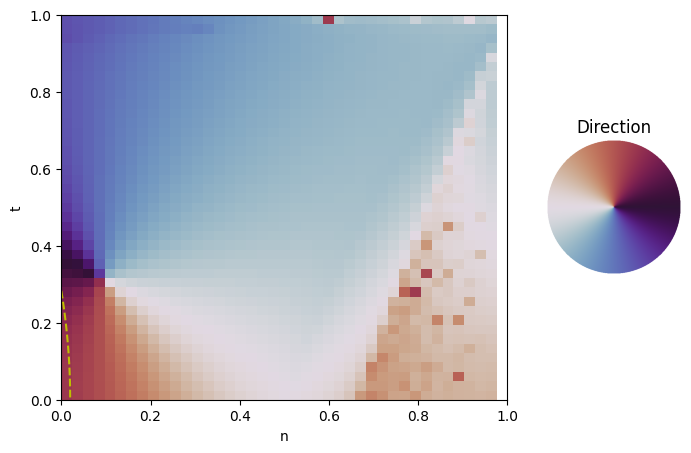

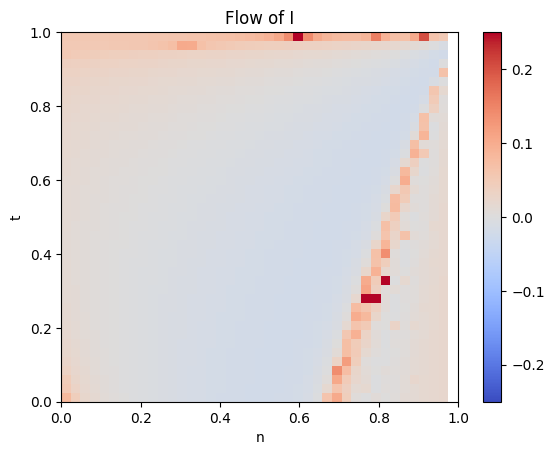

100%|██████████| 41/41 [00:17<00:00,  2.30it/s]


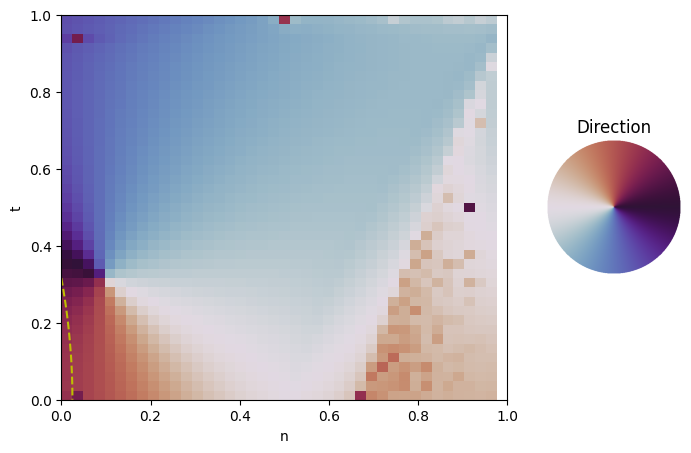

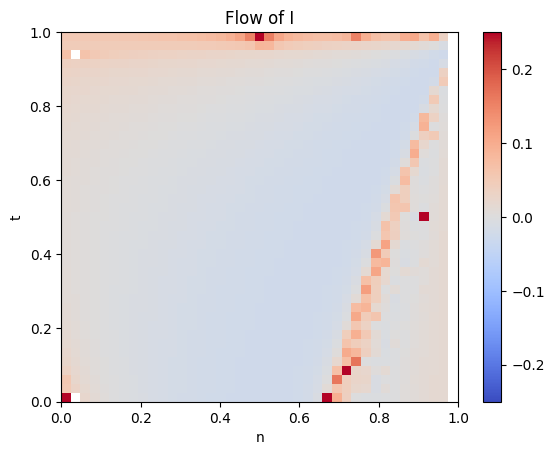

100%|██████████| 41/41 [00:17<00:00,  2.33it/s]


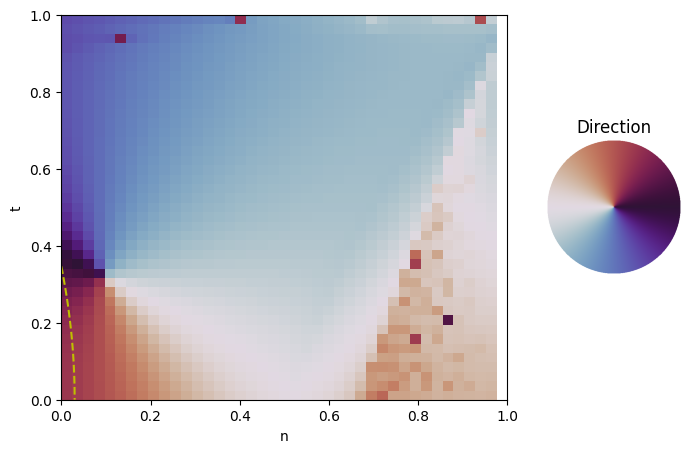

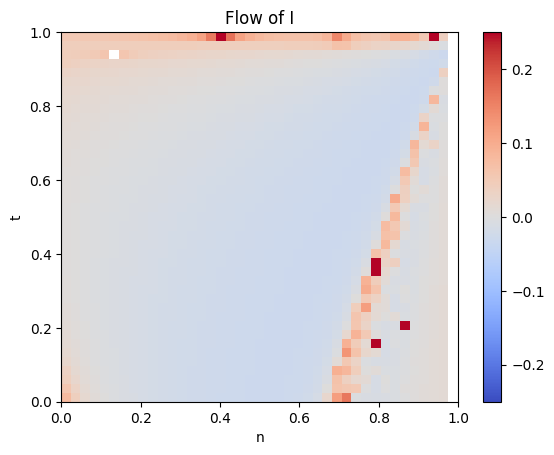

In [30]:
delta = 1.
lamb = 0.5
Is = [0.02, .025, .03]

for I in Is:
    flow_map, I_flow_map, ns, ts = get_flow_map(delta, lamb, I = I, n_bins = 41, t_bins = 41)
    plot_flow_map(np.flip(flow_map, axis = 0), np.flip(I_flow_map, axis = 0), ns, ts, plot_I_approx=True, I = I)

100%|██████████| 41/41 [00:17<00:00,  2.31it/s]


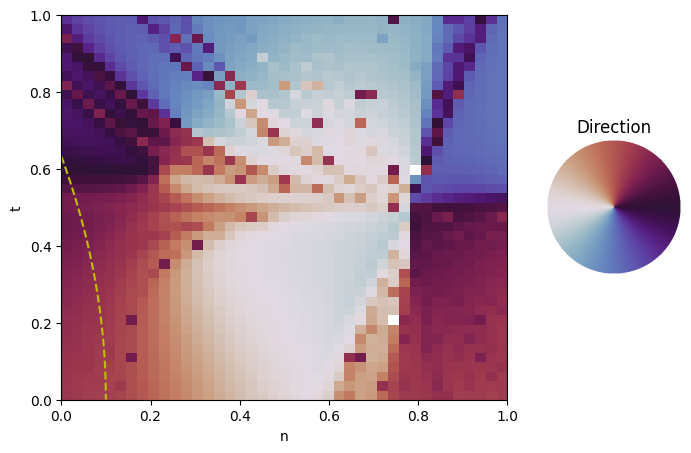

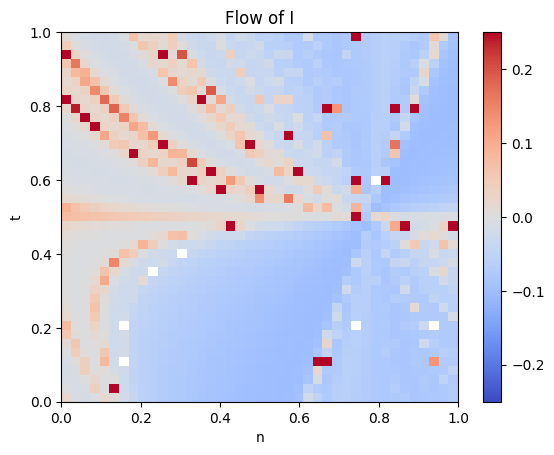

100%|██████████| 41/41 [00:17<00:00,  2.29it/s]


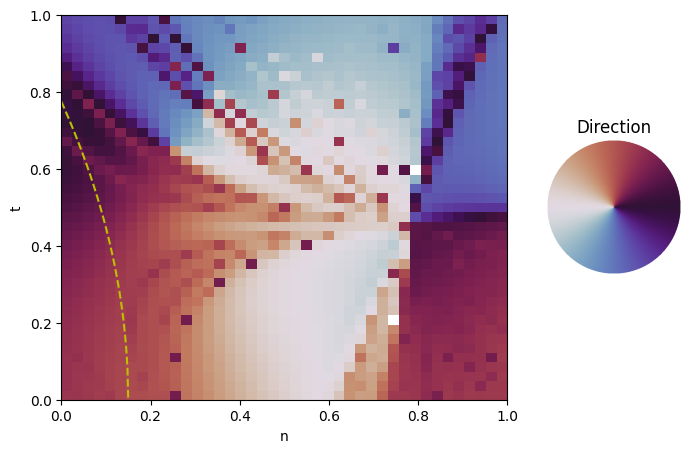

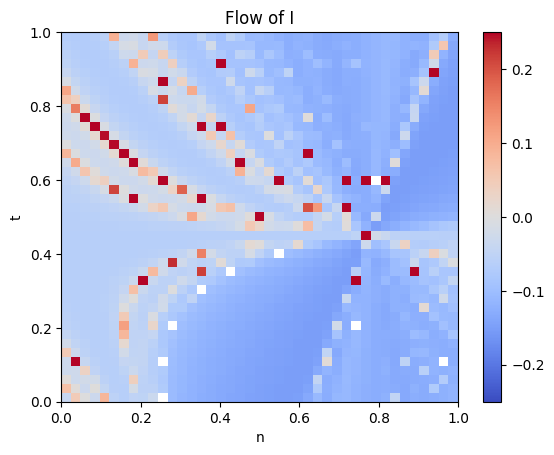

100%|██████████| 41/41 [00:17<00:00,  2.33it/s]


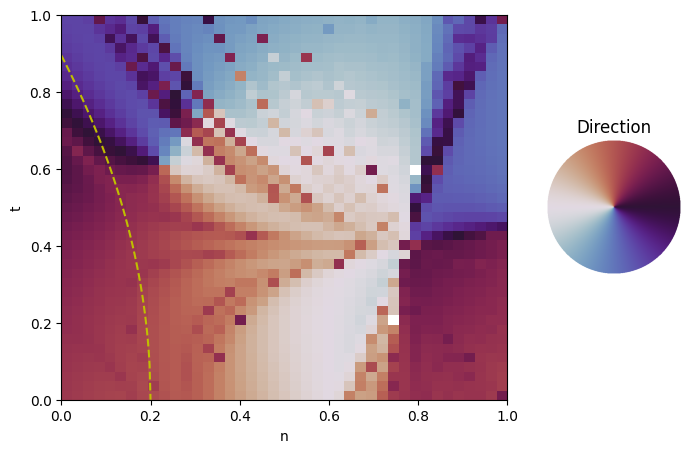

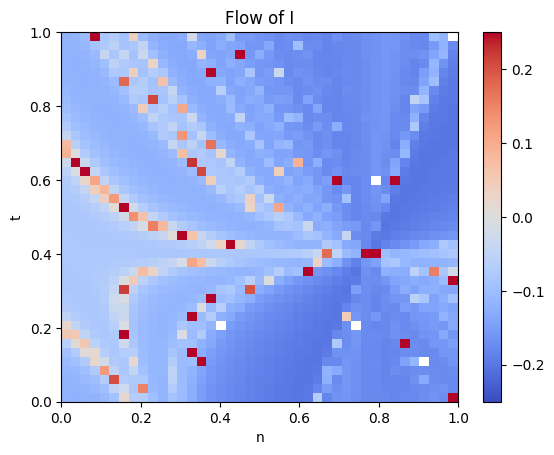

In [31]:
delta = 1.
lamb = 0.7
Is = [0.1, .15, .2]

for I in Is:
    flow_map, I_flow_map, ns, ts = get_flow_map(delta, lamb, I = I, n_bins = 41, t_bins = 41)
    plot_flow_map(np.flip(flow_map, axis = 0), np.flip(I_flow_map, axis = 0), ns, ts, plot_I_approx=True, I = I)

100%|██████████| 41/41 [00:17<00:00,  2.32it/s]


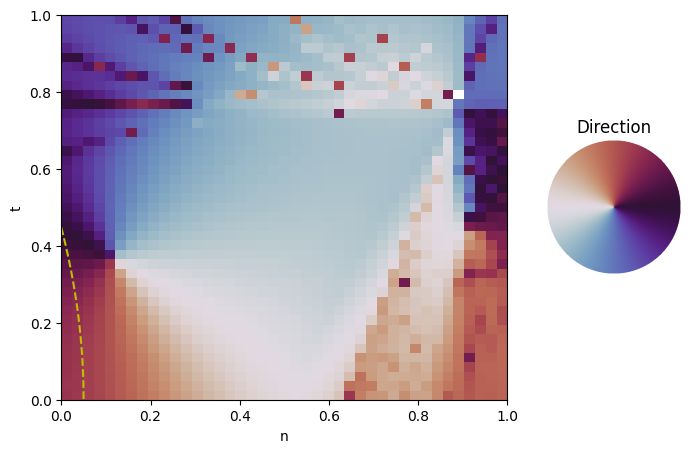

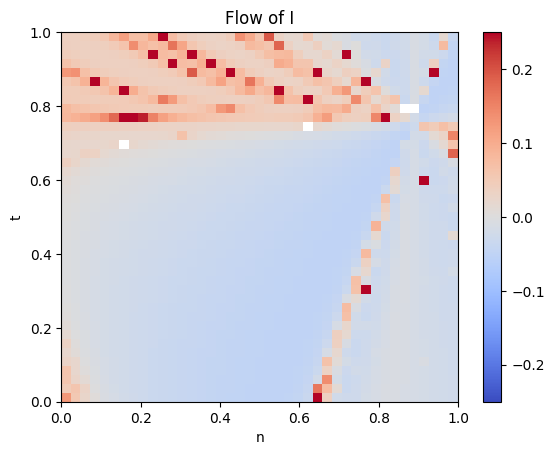

100%|██████████| 41/41 [00:17<00:00,  2.32it/s]


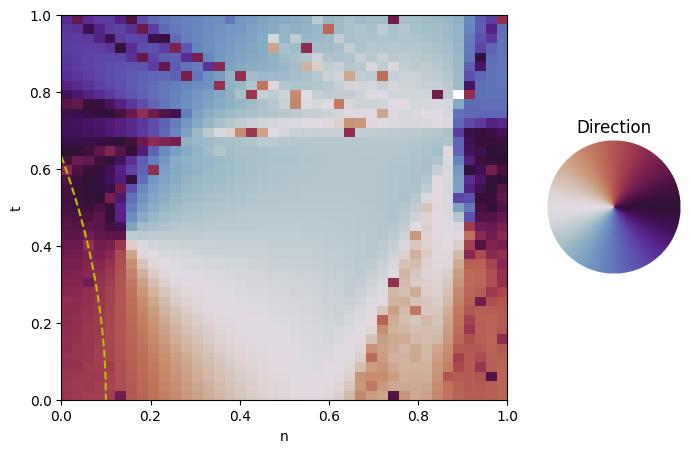

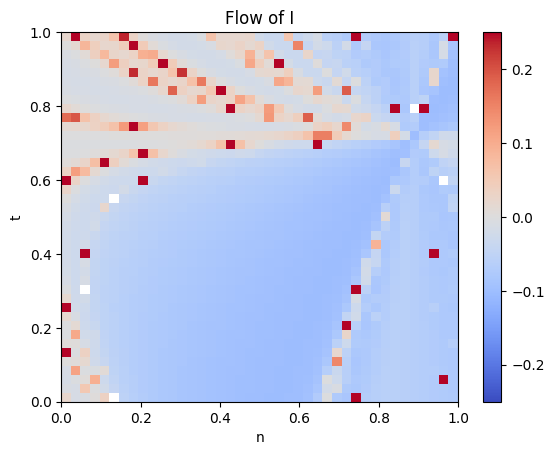

100%|██████████| 41/41 [00:17<00:00,  2.32it/s]


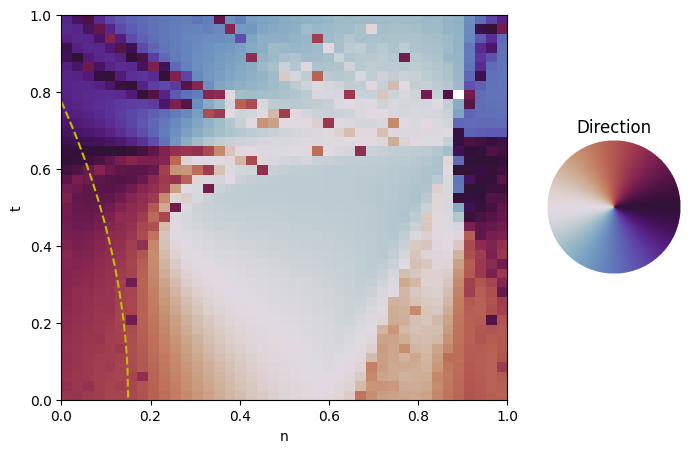

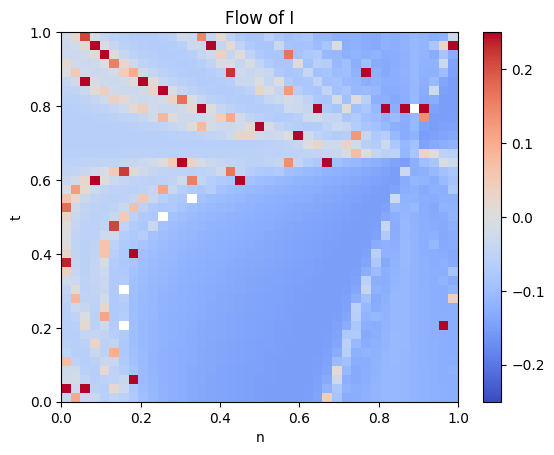

In [32]:
delta = 1.
lamb = 0.6
Is = [0.05, .1, .15]

for I in Is:
    flow_map, I_flow_map, ns, ts = get_flow_map(delta, lamb, I = I, n_bins = 41, t_bins = 41)
    plot_flow_map(np.flip(flow_map, axis = 0), np.flip(I_flow_map, axis = 0), ns, ts, plot_I_approx=True, I = I)